# Web Scrapping de La Jornada (TEST)

En este notebook se va a realizar un código capaz de extraer información de la página web (pública) del periódico ***La Jornada*** mediante la técnica conocida como **Web Scrapping** con el objetivo de recabar datos sobre eventos que puedan ser catalogados como *masacres*, los cuales deben de contar con al menos 4 cadáveres u homicidios en el mismo evento.

La extracción de información se hará sobre periódicos del **01 de Enero del 2013** al **31 de Diciembre del 2015** los cuales tienen una periodicidad diaria, salvo en fechas especiales. En la Web se tiene el registro de la Portada y Contraportada del periódico, así como el hipervínculo hacia los artículos y las noticias que aparecen en dicha portada y contraportada. Solo se tomarán en cuenta aquellas noticias y artículos que aparezcan en tales hipervínculos pues no se tiene otra forma de acceder al periódico completo. Esto, en principio, no sesga la información ni merma la obtención de datos pues los datos que se quieren extraer hacen referencia a hechos y eventos de violencia extrema, que tienen un alto impacto en la comunidad, y por lo tanto suelen aparecer en alguna de las portadas.

<div style="text-align: center; font-size: 1.5em; font-weight: bold;">
    Este notebook solo es la prueba.<br>
    Entradas: Número de días a analizar desde el 01/01/2013 (Se usaron 60)<br>
    Salidas: Modelo de Clasificación (.pkl).
</div>

En el [Modelo final](#confusion_matrix) se ve un gran modelo, con mucha robustez.

En otro notebook (llamado `LaJornada_FINAL.ipynb`) se aplica tal modelo al total de días

## Parte 1: Acceso a la página web

Para lograr la recopilación de información, primero se debe acceder de cierta forma a la página web, por lo que se utiliza la librería `request` de python, capaz de enviar peticiones tipo `GET` y `POST`. 

Luego, se usa la librería `bs4` capaz de adaptar y filtrar el formato `HTML` que devuelve la petición anterior y así poder extraer la información en texto plano.


## Parte 2: Extracción de las URL

En el flujo de trabajo, primero se extraen todas las **URL** junto al título de todas las noticias que aparecen en todas las portadas y contraportadas dentro de las fechas establecidas. Luego, se comienza con un proceso de filtrado de notas: debido a que se extraen todas las noticias, se incluyen las deportivas, económicas, de espectáculos, internacionales, entre otras secciones que no resultan de interés para el presente estudio; por lo que se pasa por un proceso de filtrado que solo mantiene aquellas noticias que pertenecen a las secciones:

- Política
- Sociedad
- Estados
- Capital

(Tarda aproximadamente 20min para 600 días)

In [94]:
# =========================================
#        Parte 1 y 2: Extraer URL's
# =========================================


# +++++ CODIGO "LEVE", SOLO ENVÍA UN REQUEST POR PORTADA (TOTAL 1095) +++++


import requests # Peticiones get y post
from bs4 import BeautifulSoup # Manejo de html
from datetime import date, timedelta # Manejo de fechas
import lxml
import re # Expresiones regulares
import time # Para ver cuanto tarda
from tqdm.notebook import tqdm # Barra de carga

t1 = time.time()

url_inicial =  "https://web.jornada.com.mx/" 
# A esta URL hay que agregarle al final AAAA/MM/DD para ver la portada y contraportada de esa fecha

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept-Language': 'es-MX,es;q=0.9,en;q=0.8',
    'Referer': 'https://www.google.com.mx/'
} # Los encabezados que "disfrazan" el script de python como si fuera un usuario de chrome

lista_urls = [] # Aqui se inicia la variable para guardar los URL's

secciones_de_interes = ['politica',
                        'sociedad',
                        'estados',
                        'capital']


# Hay 365 dias por año (el rango de fechas no incluye biciestos), y se quieren ver 3 años = 1095 días
# Se construye una función que indica la fecha tras sumar x días desde el 01/01/2013:
def fecha(i: int):
    '''Devuelve el string de la fecha que resulta de sumar i días al 2013/01/01 (AAAA/MM/DD)'''
    fecha_inicial = date.fromisoformat("2013-01-01")
    fecha_fin = fecha_inicial + timedelta(days = i)
    return re.sub(r"-","/",str(fecha_fin))


n_dias = 1095
n_url = 0 # Contador de chequeo, se puede quitar después
n_url_util = 0 # Contador de chequeo, se puede quitar después     
urls_diarios = [url_inicial]*n_dias # Aquí se va a guardar la lista de todos los URL
for i in range(n_dias):
    urls_diarios[i] = urls_diarios[i] + fecha(i)

pbar = tqdm(urls_diarios, desc = "Extrayendo URL's", unit = "dias")

for url_i in pbar:
    respuesta = requests.get(url_i, headers = headers, timeout = 8) # Hacer petición
    
    # Extrae el HTML
    if str(respuesta.status_code)[0] == '2': # Si el estatus es Exitoso...
        soup = BeautifulSoup(respuesta.text, 'html.parser')
    
        # Primero, traer todas las secciones donde hay noticias (Algunas con hipervinculos)
        lista_divs = soup.find_all("div", class_ = re.compile(r"sumario blanco p16|cabeza|aviso"))
        pbar.set_description(f"Buscando en la fecha: {str(url_i)[27:]}")
        # Extraer todas las URL de los divs
        for div in lista_divs:
            try:
                # Intentar sacar el URL (Algunos no tienen)
                a = div.find('a')
                href = str(a.get('href'))
                section = re.search(r"([^/]+)/", href)
                section = section.group(1)
                n_url += 1
                
                if section in secciones_de_interes: # Filtrar URL's
                    lista_urls.append(url_i + "/" + href )
                    n_url_util += 1
                
                pbar.set_postfix({"URL's totales":n_url,"URL's post-filtro":n_url_util})
                

            except AttributeError:
                continue
        time.sleep(0.5)

    # Luego, en la sección de abajo donde hay 2 o 3 noticias por sección, se extraen de un XML:
    url_xml = url_i + '/dir.xml'
    respuesta_xml = requests.get(url_xml, headers = headers, timeout = 10)
    if str(respuesta_xml.status_code)[0] == '2': # Si el estatus es Existoso...
        soup_xml = BeautifulSoup(respuesta_xml.content, 'lxml-xml') # Recoger el html
        
        # Primero, traer todas las secciones donde hay noticias (Algunas con hipervinculos)
        lista_items = soup_xml.find_all("Item")
        
        # Extraer las URL de los Items
        for item in lista_items:
            try:
                url_id = str(item.get('id'))
                url_section = str(item.get('section'))
                n_url += 1
                if url_section in secciones_de_interes: # Filtrar URL's
                    lista_urls.append( url_i + "/" + url_section + "/" + url_id )
                    n_url_util += 1
            except Exception as e:
                continue
        time.sleep(0.4)
        
print(f"\n\nEl programa tardó: {time.time()-t1:10.4f} segundos")
print(f"\nSe encontraron {n_url:8d} URL's en {n_dias:5d} periódicos, de las cuales tras filtrar por secciones solo se mantienen {n_url_util:6d} URL's")

Extrayendo URL's:   0%|          | 0/600 [00:00<?, ?dias/s]



El programa tardó:  1276.8957 segundos

Se encontraron    84204 URL's en   600 periódicos, de las cuales tras filtrar por secciones solo se mantienen  47352 URL's


## Parte 3: Filtrado de información

De las noticias anteriormente extraidas, muchas no hacen referencia a ningun evento criminal o violento, por lo que se realiza un segundo filtrado.
Solo se mantienen las URL tales que en el contenido de la noticia (ya sea en el título, pies de página o los párrafos) contenga alguna de las siguientes ***palabras clave*** o sus variantes (plurales, singulares, masculinos, femeninos, conjugaciones).

- Masacre(s), masacraron, masacrado(s)
- Matanza(s)
- Multihomicidio(s)
- Plurihomicidio(s)
- Exterminio(s), exterminad(os-as), exterminación
- Asesinato(s), asesinad(os-as), asesin(os-as)
- Cadáver(es)
- Homicidio(s), homicida
- Muerte(s), muerto(s), mueren
- Murieron
- Matar, mataron
- Sin vida
- Perdieron la vida
- Agresión, agresores, agredidos, agredió, agredieron
- Balacera
- Tiroteo(s), tirotearon
- Disparó, Dispararon, Disparad(os-as)
- Defunción, defunciones
- Fallecido, fallecida, fallecieron, falleció
- Feminicidio, feminicidios, feminicida
- Torturad(os-as), Tortura(s)
- Maniatad(os-as) = Con manos atadas
- Decapitad(os-as)
- Desmembrad(os-as)
- Ejecucion(es), ejecutó, ejecutad(os-as)
- Abatid(os-as), Abatieron, Abaten, Abatió

Aquellas noticias que tengan alguna de estas palabras, serán guardadas en un archivo de excel (`.xlsx`) antes de seguir analizando la siguiente noticia, esto con el fin de tener un modo de protección en caso de que los *request* sean bloqueados; de esta manera no se perderá la información ya recopilada

(Tardó 1.5h para 60 días, se calculan como 12h para 600 días. **Es el paso mas tardado**)

In [95]:
# =====================================
#       Parte 2: Buscar KeyWords       
# =====================================


# +++++ CÓDIGO PESADO, ENVÍA UN REQUEST POR *NOTICIA* (TOTAL APROX = 80,000) +++++


import re
import time
import json

t1 = time.time()

def guardar_progreso(noticia):
    with open("noticias_con_match.jsonl", "a", encoding = "utf-8") as file:
        file.write(json.dumps(noticia, ensure_ascii=False) + "\n")

# Definimos las raíces para cubrir plurales y variaciones
# \b al inicio y final asegura que busque palabras completas y no partes de otras
patrones = [
    r"masacr\w+",                  # Masacre(s), masacraron, masacrado(s)
    r"matanz\w+",                  # Matanza(s)
    r"multihomicidio\w*",          # Multihomicidio(s)
    r"plurihomicidio\w*",          # Plurihomicidio(s)
    r"extermin\w+",                # Exterminio(s), exterminad(os-as), exterminación
    r"asesin\w+",                  # Asesinato(s), asesinad(os-as), asesin(os-as)
    r"cad[aá]ver\w*",              # Cadáver(es)
    r"homicid\w+",                 # Homicidio(s), homicida
    r"muer\w+",                    # Muerte(s), muerto(s), mueren
    r"murieron",                   # Palabra exacta
    r"matar\w*",                   # Matar, mataron
    r"sin vida",                   # Frase exacta
    r"perdieron la vida",          # Frase exacta
    r"agres\w+",                   # Agresión, agresores, agredidos, agredió, agredieron
    r"balacera\w*",                # Palabra exacta
    r"tirote\w+",                  # Tiroteo(s), tirotearon
    r"dispar\w+",                  # Disparó, Dispararon, Disparad(os-as)
    r"defunci\w+",                 # Defunción, defunciones
    r"falleci\w+",                 # Fallecido, fallecida, fallecieron, falleció
    r"feminicid\w+",               # Feminicidio, feminicidios, feminicida
    r"tortur\w+",                  # Torturad(os-as), Tortura(s)
    r"maniatad\w+",                # Maniatad(os-as) = Con manos atadas
    r"decapita\w+",                # Decapitad(os-as)
    r"desmembrad\w+",              # Desmembrad(os-as)
    r"\bejecu(tó|taron|tados?|tadas?|ci[oó]n(es)?)\w+", # Para evitar "Ejecutivo o Ejecutiva" pero añadir "Ejecutados" o "ejecuciones"
    r"abati\w+"                    # Abatid(os-as), Abatieron, Abaten, Abatió
    
]

# Unimos todo con el operador OR (|)
regex_final = re.compile("|".join(patrones), re.IGNORECASE)

import requests
from bs4 import BeautifulSoup
import re
import random
from tqdm.notebook import tqdm

# Tu lista de URLs únicas (usa set() para asegurar que no haya repetidas)
urls_unicas = list(set(lista_urls))
n_urls = len(urls_unicas)
noticias_relevantes = []
matchs = 0
pbar = tqdm(urls_unicas, desc="Intentando scraping", unit="url")
url_procesadas = set()

for i, url in enumerate(pbar,1):
    try:
        time.sleep(abs(random.gauss(.5,0.08))) # Esperamos un poco para no saturar el servidor
        
        # Descarga con timeout para que no se trabe el script
        respuesta = requests.get(url, headers = headers, timeout=10)
        
        # Procesamos el texto completo de una vez
        sopa = BeautifulSoup(respuesta.content, 'html.parser')
        
        # Buscamos en todo el artículo (Ignoramos encabezado, menús, publicidad, etc)
        art = sopa.find("div", id = "article-text")
        
        texto_completo = art.get_text(separator=' ', strip=True)
        
        # Buscamos el match
        match = regex_final.search(texto_completo)
        
        
        if match:
            # Guardamos un diccionario de la noticia
            noticia = {
                'url': url,
                'keyword_detectada': match.group(),
                'texto': texto_completo 
            }
            # Si encontramos algo, guardamos y salimos del loop de esta URL
            # Guardamos el match.group() para saber cual palabra activó la alerta
            noticias_relevantes.append(noticia)

            if url not in url_procesadas:
                url_procesadas.add(url)
                guardar_progreso(noticia)
            
            matchs += 1    
            url_display = str(url)[27:]
    
            # Actualizamos la descripción (línea superior)
            pbar.set_description(f"Intentando {url_display}")
            
            # Actualizamos las estadísticas (a la derecha de la barra)
            pbar.set_postfix({"Matchs": matchs})
            

    except Exception as e:
        print(f"Error en {url}:\t{e}")
        continue

t2 = time.time()
print(f"\nEl programá se ejecutó durante {(int(t2-t1)//60)//60:3d} horas {(int(t2-t1)//60)%60:3d} min {(t2-t1)%60:6.3f} seg")

print(f"\nSe Obtuvieron {matchs} noticias con coincidencias de alguna palabra clave, y se guardaron para su posterior análisis")

Intentando scraping:   0%|          | 0/42583 [00:00<?, ?url/s]

KeyboardInterrupt: 

## Parte 4: Análisis de lenguaje natural

Tras filtrar solo aquellas noticias que tengan coincidencias con alguna de las palabras clave, se requiere poder analizar de manera precisa y eficiente el contenido de la noticia para identificar el número de víctimas, el lugar de ocurrencia, la fecha y alguna otra característica del evento que se desee analizar. Para esto, se utilizará la librería `spaCy` en su módulo de `es_core_news_lg`, el cual es la versión más grande, y por lo tanto, potente y precisa para procesar texto escrito en español y categorizarlo (Ubicación, Personajes, Tiempo, etc.).

Tras este análisis de lenguaje natural (NLP), se guardarán los datos en un archivo para una comprobación humana de una muestra, el guardado se hará individualmente tras cada noticia. Esta es una técnica de *programación defensiva* y permite una mayor seguridad ante bloqueos de la página web, o errores del código.

In [20]:
# Limpiar datos
from IPython.display import clear_output
import pandas as pd
import time
import re


# Definimos las palabras que se quieran asociar al número de victimas
keywords = [r"muert[oa]s",
            r"víctimas",
            r"cuerpos",
            r"occisos",
            r"fallecid[oa]s",
            r"cadáver(?:es)",
            r"restos? humanos?",
            r"ejecutad[oa]s?",
            r"abatid[oa]s?", 
            r"decesos?",
            r"homicidios?",
            r"asesinatos?"]
string_kw = "|".join(keywords) # Aqui se unen en una string separados por "|"

# El número de víctimas podría estar con número o con letras (esta expresion regular solo acepta hasta el número 20 en letras)
numeros = [r"un[oa]?",
          r"dos",
          r"tres",
          r"cuatro",
          r"cinco",
          r"seis",
          r"siete",
          r"ocho",
          r"nueve",
          r"diez",
          r"once",
          r"doce",
          r"trece",
          r"catorce",
          r"quince",
          r"dieciséis",
          r"diecisiete",
          r"dieciocho",
          r"diecinueve",
          r"veinte",
          r"\d+"]
string_num = "|".join(numeros)

texto_a_num = {
    "un"        : 1, "una": 1, "uno": 1,
    "dos"       : 2,
    "tres"      : 3,
    "cuatro"    : 4,
    "cinco"     : 5,    
    "seis"      : 6,
    "siete"     : 7,
    "ocho"      : 8,
    "nueve"     : 9,
    "diez"      : 10,
    "once"      : 11,
    "doce"      : 12,
    "trece"     : 13,
    "catorce"   : 14,
    "quince"    : 15,
    "dieciséis" : 16,
    "diecisiete": 17,
    "dieciocho" : 18,
    "diecinueve": 19,
    "veinte"    : 20
}

# La regex final (usando el puente de 0 a 3 palabras)
patron_victimas = re.compile(
    rf"\b(?:({string_num})\s+(?:[\w,\.]+\s+){{0,5}}(?:{string_kw})|(?:{string_kw})\s+(?:[\w,\.]+\s+){{0,5}}({string_num}))\b",
    flags=re.IGNORECASE | re.UNICODE
)


def procesar_num_victimas(noticia : str):
    
    match_victimas = re.search(patron_victimas, noticia)

    if match_victimas:
        # Guardamos el match (el número de victimas)
        victimas_re = match_victimas.group(1) or match_victimas.group(2)
        victimas_re = victimas_re.lower().strip()
        
        # El Match podría ser el texto "siete" o el número 4. Pasamos todo a int
        if victimas_re.isdigit():
            victimas_re = int(victimas_re)
        else:
            victimas_re = texto_a_num.get(victimas_re, 1)
        resultado_final = victimas_re
    else: 
        # Si no hay match de RegEx, guardamos la noticia aparte (codigo 0)
        resultado_final = 0
            
    return resultado_final

# Cargar datos para etiquetar
df_noticias = pd.read_json("noticias_con_match.jsonl", lines = True)

def limpiar_minimo(texto):
    texto = texto.lower()
    # Eliminar números de patrullas, fechas o años (4 dígitos) que confunden
    texto = re.sub(r'\b\d{4}\b', '', texto) 
    # Eliminar puntuación básica
    texto = re.sub(r'[^\w\s]', '', texto)
    return texto

df_noticias['texto_limpio'] = df_noticias['texto'].apply(limpiar_minimo)

# Crear columna
df_noticias["num_vict"] = df_noticias["texto_limpio"].apply(procesar_num_victimas)

# Categorizar
def es_masacre(n):
    if n >=4 and n<100:
        return 1
    else :
        return 0
        
df_noticias["es_masacre"] = df_noticias["num_vict"].apply(es_masacre)

#df_noticias.head(30)

df_si = df_noticias[df_noticias['es_masacre'] == 1]
df_no = df_noticias[df_noticias['es_masacre'] == 0]

print(df_no.shape, df_si.shape)
df_noticias.head()

(1139, 6) (191, 6)


,url,keyword_detectada,texto,texto_limpio,num_vict,es_masacre
0,https://web.jornada.com.mx/2013/02/02/politica...,murieron,De la Redacción Periódico La Jornada Sábado 2...,de la redacción periódico la jornada sábado 2...,5,1
1,https://web.jornada.com.mx/2013/01/25/estados/...,agresiones,Cientos de alumnos y padres de familia de la p...,cientos de alumnos y padres de familia de la p...,1,0
2,https://web.jornada.com.mx/2013/02/24/estados/...,muerte,Mariana Chávez Corresponsal Periódico La Jorna...,mariana chávez corresponsal periódico la jorna...,0,0
3,https://web.jornada.com.mx/2013/02/24/sociedad...,disparidades,Laura Poy Solano Periódico La Jornada Domingo ...,laura poy solano periódico la jornada domingo ...,0,0
4,https://web.jornada.com.mx/2013/02/18/politica...,muerte,De la Redacción Periódico La Jornada Lunes 18 ...,de la redacción periódico la jornada lunes 18 ...,0,0


### Calibrar al Modelo de Clasificación

Con la librería `scikit-learn` se entrena a un modelo de Clasificación (Aprendizaje Supervisado) con aproximadamente 400 datos (+200 clasificados como masacre). Se repite el proceso un total de 300 veces, generando un modelo nuevo en cada ocasión para verificar la estabilidad, confiabilidad y robustez del mismo ante un cambio en las muestras tanto de entrenamiento como de prueba.

  0%|          | 0/300 [00:00<?, ?it/s]

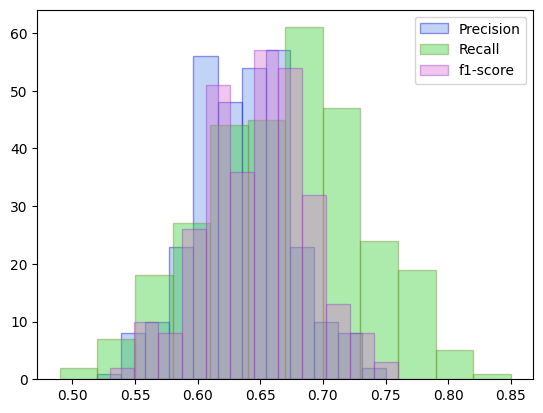

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm


l_p  = []
l_r  = []
l_f1 = []
def modelo(test_sz = 0.3, weights = {0:1, 1:1}, nrange=(1,2)):
    
    # Muestreamos n=170 con categoria 'cero' para que sea proporcional a las otras (cada categoria n = 170)
    df_nada_sample = df_no.sample(n=200) 
    
    # Unimos el dataset final balanceado (aprox 500 registros totales)
    df_balanceado = pd.concat([df_si, df_nada_sample]).sample(frac=1)
    
    X = df_balanceado['texto_limpio']
    y = df_balanceado['es_masacre']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_sz, stratify=y)
    
    # Vectorizador optimizado para 500 registros
    vectorizer = TfidfVectorizer(
        max_features=500, 
        ngram_range=nrange, # ¡Importante! Verá "tres personas muertas" como una sola unidad
        strip_accents='unicode'
    )
    
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)
    
    # Probamos con LinearSVC, que es excelente para texto con pocos datos
    model = LinearSVC(class_weight=weights)
    model.fit(X_train_vec, y_train)
    
    y_pred = model.predict(X_test_vec)
    reporte = classification_report(y_test, y_pred)
    match = re.search(r"^\s*1\s+(0\.\d+)\s+(0\.\d+)\s+(0\.\d+)", reporte, re.MULTILINE)
    precision, recall, f1 = map(float, match.groups())
    return (precision, recall, f1, model, X_test)



n = 300

for i in tqdm(range(n)):
    # ------------ SWEET POINT test_sz=0.35, weights={0:1, 1:1.2}, nrange=(1,2) --------------
    corrida = modelo(test_sz=0.35, weights={0: 1,  1: 1.2}, nrange=(1, 2))
    l_p.append(corrida[0])
    l_r.append(corrida[1])
    l_f1.append(corrida[2])

plt.hist(l_p, bins = 12, label = 'Precision', color = 'cornflowerblue', edgecolor = 'mediumblue', alpha=0.4)
plt.hist(l_r, bins = 12, label = 'Recall', color = "limegreen", edgecolor = "olivedrab", alpha=0.4)
plt.hist(l_f1, bins = 12, label = 'f1-score', color = "orchid", edgecolor = 'darkorchid', alpha = 0.4)
plt.legend()
plt.show()

Ahora se interpretan los resultados obtenidos.

Solo se interpretarán los parámetros de la fila del número ***1***, pues es el caso que interesa registrar (cuando sí hay masacre).

- La *precision* mide qué proporción de los Positivos que predijo el modelo son ***True Positives***, es decir, de todos los que predijo como positivos, en cuántos estaba bien.
- El *recall* mide qué proporción del total real de Positivos los predijo el modelo, es decir, cuántas de las masacres que hubo, las está capturando el modelo.
- El *f1-score* es la **media armónica** de la precisión y el recall, es decir $\displaystyle f1-score = \frac{2*precision*recall}{precision+recall}$, también se puede ver como: $\displaystyle f1-score=\frac{TP}{TP+\frac{1}{2}(FP+FN)}$ donde $TP$ son los True positives, aquellos casos donde el modelo predijo correctamente las masacres; los $FP$ son False positives, los casos donde el modelo predijo una masacre pero realmente no la hubo; y $FN$ son los false negatives, los casos donde el modelo predijo que **no** había masacre, pero en realidad sí había. Esta interpretación es más sencilla pues deja ver que si tienes más True positives (predicciones correctas), el f1-score aumenta. Mientras que al tener más False Positives o False negatives (predicciones incorrectas), el f1-score disminuye


Lo ideal es que tanto la *precision* como el *recall* sean lo más cercanos a uno (1) como sea posible, **simultaneamente**. Esto resulta a menudo imposible, pues existe una relación que no permite que ambos crezcan de manera sencilla.

En lugar de monitorear tanto la precisión como el recall, se puede simplemente monitorear el *f1-score*, mientras más alto es mejor (cercano a 1); aunque hay que tener cuidado si es demasiado alto (+0.95) pues probablemente se tendría el fenómeno de **sobredispersión**. Este fenómeno se da cuando el modelo en lugar de *"aprender"* de tus datos, los *"memoriza"*, y aunque se ajusta perfectamente a tus datos de prueba, suele resultar muy malo para poder predecir y modelar datos que no sean los de entrenamiento.


En este caso, se probaron distintas configuraciones del modelo, ajustando los parámetros de:
- Tamaño de la muestra de prueba
- Ponderación de cada elemento
- Rango de N-gramas

En los histogramas previamente graficados se puede ver una gran estabilidad de las 3 variables alrededor del valor $0.65$, con el *recall* ligeramente más inclinado hacia valores superiores. Un hallazgo importante es que prácticamente ningún modelo tuvo alguna variable menor a $0.50$, esto es buena ya que el valor de $0.50$ es el que se obtendría clasificando puramente al azar.

Tras esta prueba, se procede a elegir uno de los modelos generados, que sea representativo para posteriormente utilizarlo en la fase de **producción** con el total de noticias y se presentan sus parámetros
<a id="confusion_matrix"></a>

In [24]:
# Tras la prueba de robustez se toma un modelo representativo

import pandas as pd
import re
import joblib # Para guardar el modelo
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. PREPARACIÓN DEL DATASET TOTAL ---
# Usamos la misma lógica de tu muestreo para tener el dataset balanceado final
df_nada_sample = df_no.sample(n=200, random_state=42) 
df_final = pd.concat([df_si, df_nada_sample]).sample(frac=1, random_state=42)

X_final = df_final['texto_limpio']
y_final = df_final['es_masacre']

# --- 2. VECTORIZACIÓN ---
# Usamos los parámetros que encontraste en tu "Montecarlo"
vectorizer = TfidfVectorizer(
    max_features=500, 
    ngram_range=(1, 2), 
    strip_accents='unicode'
)

# Ajustamos con todos los datos etiquetados
X_vec = vectorizer.fit_transform(X_final)

# --- 3. ENTRENAMIENTO DEL MODELO "EL ELEGIDO" ---
# Usamos los pesos que dieron el sweet point en tu histograma
modelo_final = LinearSVC(class_weight={0: 1, 1: 1.2}, random_state=42)
modelo_final.fit(X_vec, y_final)

# --- 4. AUDITORÍA DE FALSOS POSITIVOS (FP) ---
# Vamos a ver dónde el modelo se equivoca "dentro" de lo que ya conocemos
y_pred = modelo_final.predict(X_vec)

# Filtramos los casos donde el modelo dice 1 pero la realidad (o tu regex) dijo 0
mask_fp = (y_final == 0) & (y_pred == 1)
df_fp = df_final[mask_fp].copy()

# --- 5. GUARDAR PARA PROCESAR LAS 80,000 NOTICIAS ---
# Esto es vital para no tener que repetir el proceso
joblib.dump(modelo_final, 'modelo_masacres_final.pkl')
joblib.dump(vectorizer, 'vectorizador_final.pkl')
print("Modelo y vectorizador guardados con éxito.")


# 1. Generar predicciones sobre el dataset completo
y_pred_final = modelo_final.predict(X_vec)

# 2. Calcular la matriz de confusión
cm = confusion_matrix(y_final, y_pred_final)

# 3. Graficar de forma profesional
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Masacre (0)', 'Masacre (1)'], 
            yticklabels=['No Masacre (0)', 'Masacre (1)'])

plt.title('Matriz de Confusión: Modelo Final (Dataset Etiquetado)')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Etiqueta/Regex)')
plt.show()

# 4. Imprimir métricas finales de este modelo "entrenado al 100%"
print("Métricas finales sobre el dataset de entrenamiento:")
print(classification_report(y_final, y_pred_final))

Se encontraron 24 Falsos Positivos en el set de entrenamiento.
--------------------------------------------------
ID: 875
Texto: votación ayer en san lázaro también se guardó un minuto de silencio por las víctimas en pemex foto jesús villaseca alfredo méndez periódico la jornada jueves  7 de febrero de  p 7 la procuraduría general de la república pgr citará a declarar en calidad de testigo a césar falcón director adjunto de c...
------------------------------
ID: 245
Texto: habitantes de la colonia fuentes de aragón municipio de ecatepec estado de méxico bloquearon ayer la avenida central para exigir la liberación de román gonzález gaviada médico que mató a dos presuntos delincuentes los manifestantes alegaron que se defendió foto mario a núñez lópez javier salinas ces...
------------------------------
ID: 856
Texto: familiares de desaparecidos se reunieron en la ciudad de chihuahua con integrantes de el barzón quienes apoyan la demanda de resultados en las investigaciones los agricult